In [ ]:
# setup
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv,noheader
!nvcc --version | tail -1

NVIDIA A100-SXM4-40GB, 40960 MiB, 8.0
Build cuda_12.8.r12.8/compiler.35583870_0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, subprocess
PROJECT = '/content/drive/MyDrive/galaxy_merger'
WORK = '/content/galaxy_merger'
SNAPS = os.path.join(PROJECT, 'snapshots_3M')
os.makedirs(SNAPS, exist_ok=True)

if os.path.exists(os.path.join(PROJECT, 'src')):
    if os.path.exists(WORK): shutil.rmtree(WORK)
    shutil.copytree(PROJECT, WORK, ignore=shutil.ignore_patterns('snapshots*', '*.bin'))
    os.makedirs(f'{WORK}/snapshots', exist_ok=True)
    print('copied from drive')
else:
    print(f'upload src/ to {PROJECT}')

os.chdir(WORK)
!ls src/

Mounted at /content/drive
copied from drive
gravity.cu  main.cu


In [ ]:
# detect arch and compile
cc = subprocess.run(['nvidia-smi','--query-gpu=compute_cap','--format=csv,noheader'],
                    capture_output=True, text=True).stdout.strip().replace('.','')
ARCH = f'sm_{cc}'
print(f'compiling for {ARCH}')

!nvcc -O3 -arch={ARCH} -Iinclude src/gravity.cu src/main.cu -o galaxy_merger 2>&1
!ls -la galaxy_merger

In [ ]:
%%time
# generate 3M particle merger ICs
!python generate_ics.py --N 3000000 --output ic_3M.bin \
    --separation 100 --pericenter 20 --inclination 20 --seed 42

N=3000000
M51a:
  rotation curve: 5 kpc -> 194  10 kpc -> 201  20 kpc -> 196  km/s
  gas: 600000 particles, mfrac=0.983
  DM: 1200000 particles, mfrac=0.961
  disk: 600000 particles, mfrac=0.983
  bulge: 150000 particles, mfrac=0.907
NGC5195:
  rotation curve: 5 kpc -> 167  10 kpc -> 158  20 kpc -> 147  km/s
  gas: 90000 particles, mfrac=0.983
  DM: 300000 particles, mfrac=0.961
  disk: 150000 particles, mfrac=0.983
  bulge: 60000 particles, mfrac=0.907
  orbit: sep=100 rperi=20 vr=316 vt=158 km/s
  wrote ic_3M.bin: N=3150002 (138.6 MB)
  70.2s
CPU times: user 103 ms, sys: 20.6 ms, total: 123 ms
Wall time: 1min 10s


In [ ]:
# quick sanity check
import sys; sys.path.insert(0, WORK)
from analysis import read_snapshot
import numpy as np

s = read_snapshot('ic_3M.bin')
print(f"N={s['N_total']:,}")
for pt, nm in [(0,'DM'),(1,'Disk'),(2,'Bulge'),(3,'Gas'),(5,'BH')]:
    m = s['ptype']==pt
    if m.sum()>0:
        v = np.sqrt(s['vx'][m]**2+s['vy'][m]**2+s['vz'][m]**2)
        print(f'  {nm}: N={m.sum():,}  |v|={np.median(v):.0f} km/s')

N=3,150,002
  DM: N=1,500,000  |v|=144 km/s
  Disk: N=750,000  |v|=202 km/s
  Bulge: N=210,000  |v|=186 km/s
  Gas: N=690,000  |v|=198 km/s
  BH: N=2  |v|=177 km/s


In [ ]:
%%time
# production run: 1.2 Gyr, snapshots every 5 Myr
import threading, glob, time

LOCAL = f'{WORK}/snapshots_prod'
os.makedirs(LOCAL, exist_ok=True)

# background copy to Drive
stop = threading.Event()
def copier():
    while not stop.is_set():
        for f in glob.glob(f'{LOCAL}/snap_*.bin'):
            dst = os.path.join(SNAPS, os.path.basename(f))
            if not os.path.exists(dst):
                try: shutil.copy2(f, dst)
                except: pass
        stop.wait(30)

t = threading.Thread(target=copier, daemon=True); t.start()

# t_end=1.2 (~1.17 Gyr), dt_snap=0.005 (~5 Myr), dt=0.0005 (~0.5 Myr)
proc = subprocess.Popen(
    ['./galaxy_merger', 'ic_3M.bin', LOCAL, '1.2', '0.005', '0.0005'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)

for line in iter(proc.stdout.readline, ''):
    print(line.rstrip())
proc.wait()
stop.set()

# final copy
for f in glob.glob(f'{LOCAL}/snap_*.bin'):
    dst = os.path.join(SNAPS, os.path.basename(f))
    if not os.path.exists(dst): shutil.copy2(f, dst)

print(f'\nsnapshots on Drive: {len(glob.glob(os.path.join(SNAPS,"snap_*.bin")))}')

loaded 3150002 particles
read 9 fields
GPU memory: 132 MB
  snap 0000  t=0 Myr

running 1174 Myr, dt=0.5 Myr, saving every 4.9 Myr

  snap 0001  t=5 Myr
  snap 0002  t=10 Myr
  snap 0003  t=15 Myr
  snap 0004  t=20 Myr
  snap 0005  t=25 Myr
  snap 0006  t=30 Myr
  snap 0007  t=35 Myr
  snap 0008  t=40 Myr
  snap 0009  t=44 Myr
  snap 0010  t=49 Myr
  snap 0011  t=54 Myr
  snap 0012  t=59 Myr
  snap 0013  t=64 Myr
  snap 0014  t=68 Myr
  snap 0015  t=73 Myr
  snap 0016  t=78 Myr
  snap 0017  t=83 Myr
  snap 0018  t=88 Myr
  snap 0019  t=93 Myr
  snap 0020  t=98 Myr
step    200  t=98 Myr  2217.1 ms/step  ETA 1.4 h
  snap 0021  t=103 Myr
  snap 0022  t=108 Myr
  snap 0023  t=112 Myr
  snap 0024  t=117 Myr
  snap 0025  t=122 Myr
  snap 0026  t=127 Myr
  snap 0027  t=132 Myr
  snap 0028  t=137 Myr
  snap 0029  t=142 Myr
  snap 0030  t=147 Myr
  snap 0031  t=152 Myr
  snap 0032  t=157 Myr
  snap 0033  t=162 Myr
  snap 0034  t=167 Myr
  snap 0035  t=172 Myr
  snap 0036  t=177 Myr
  snap 0037 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
241 snapshots


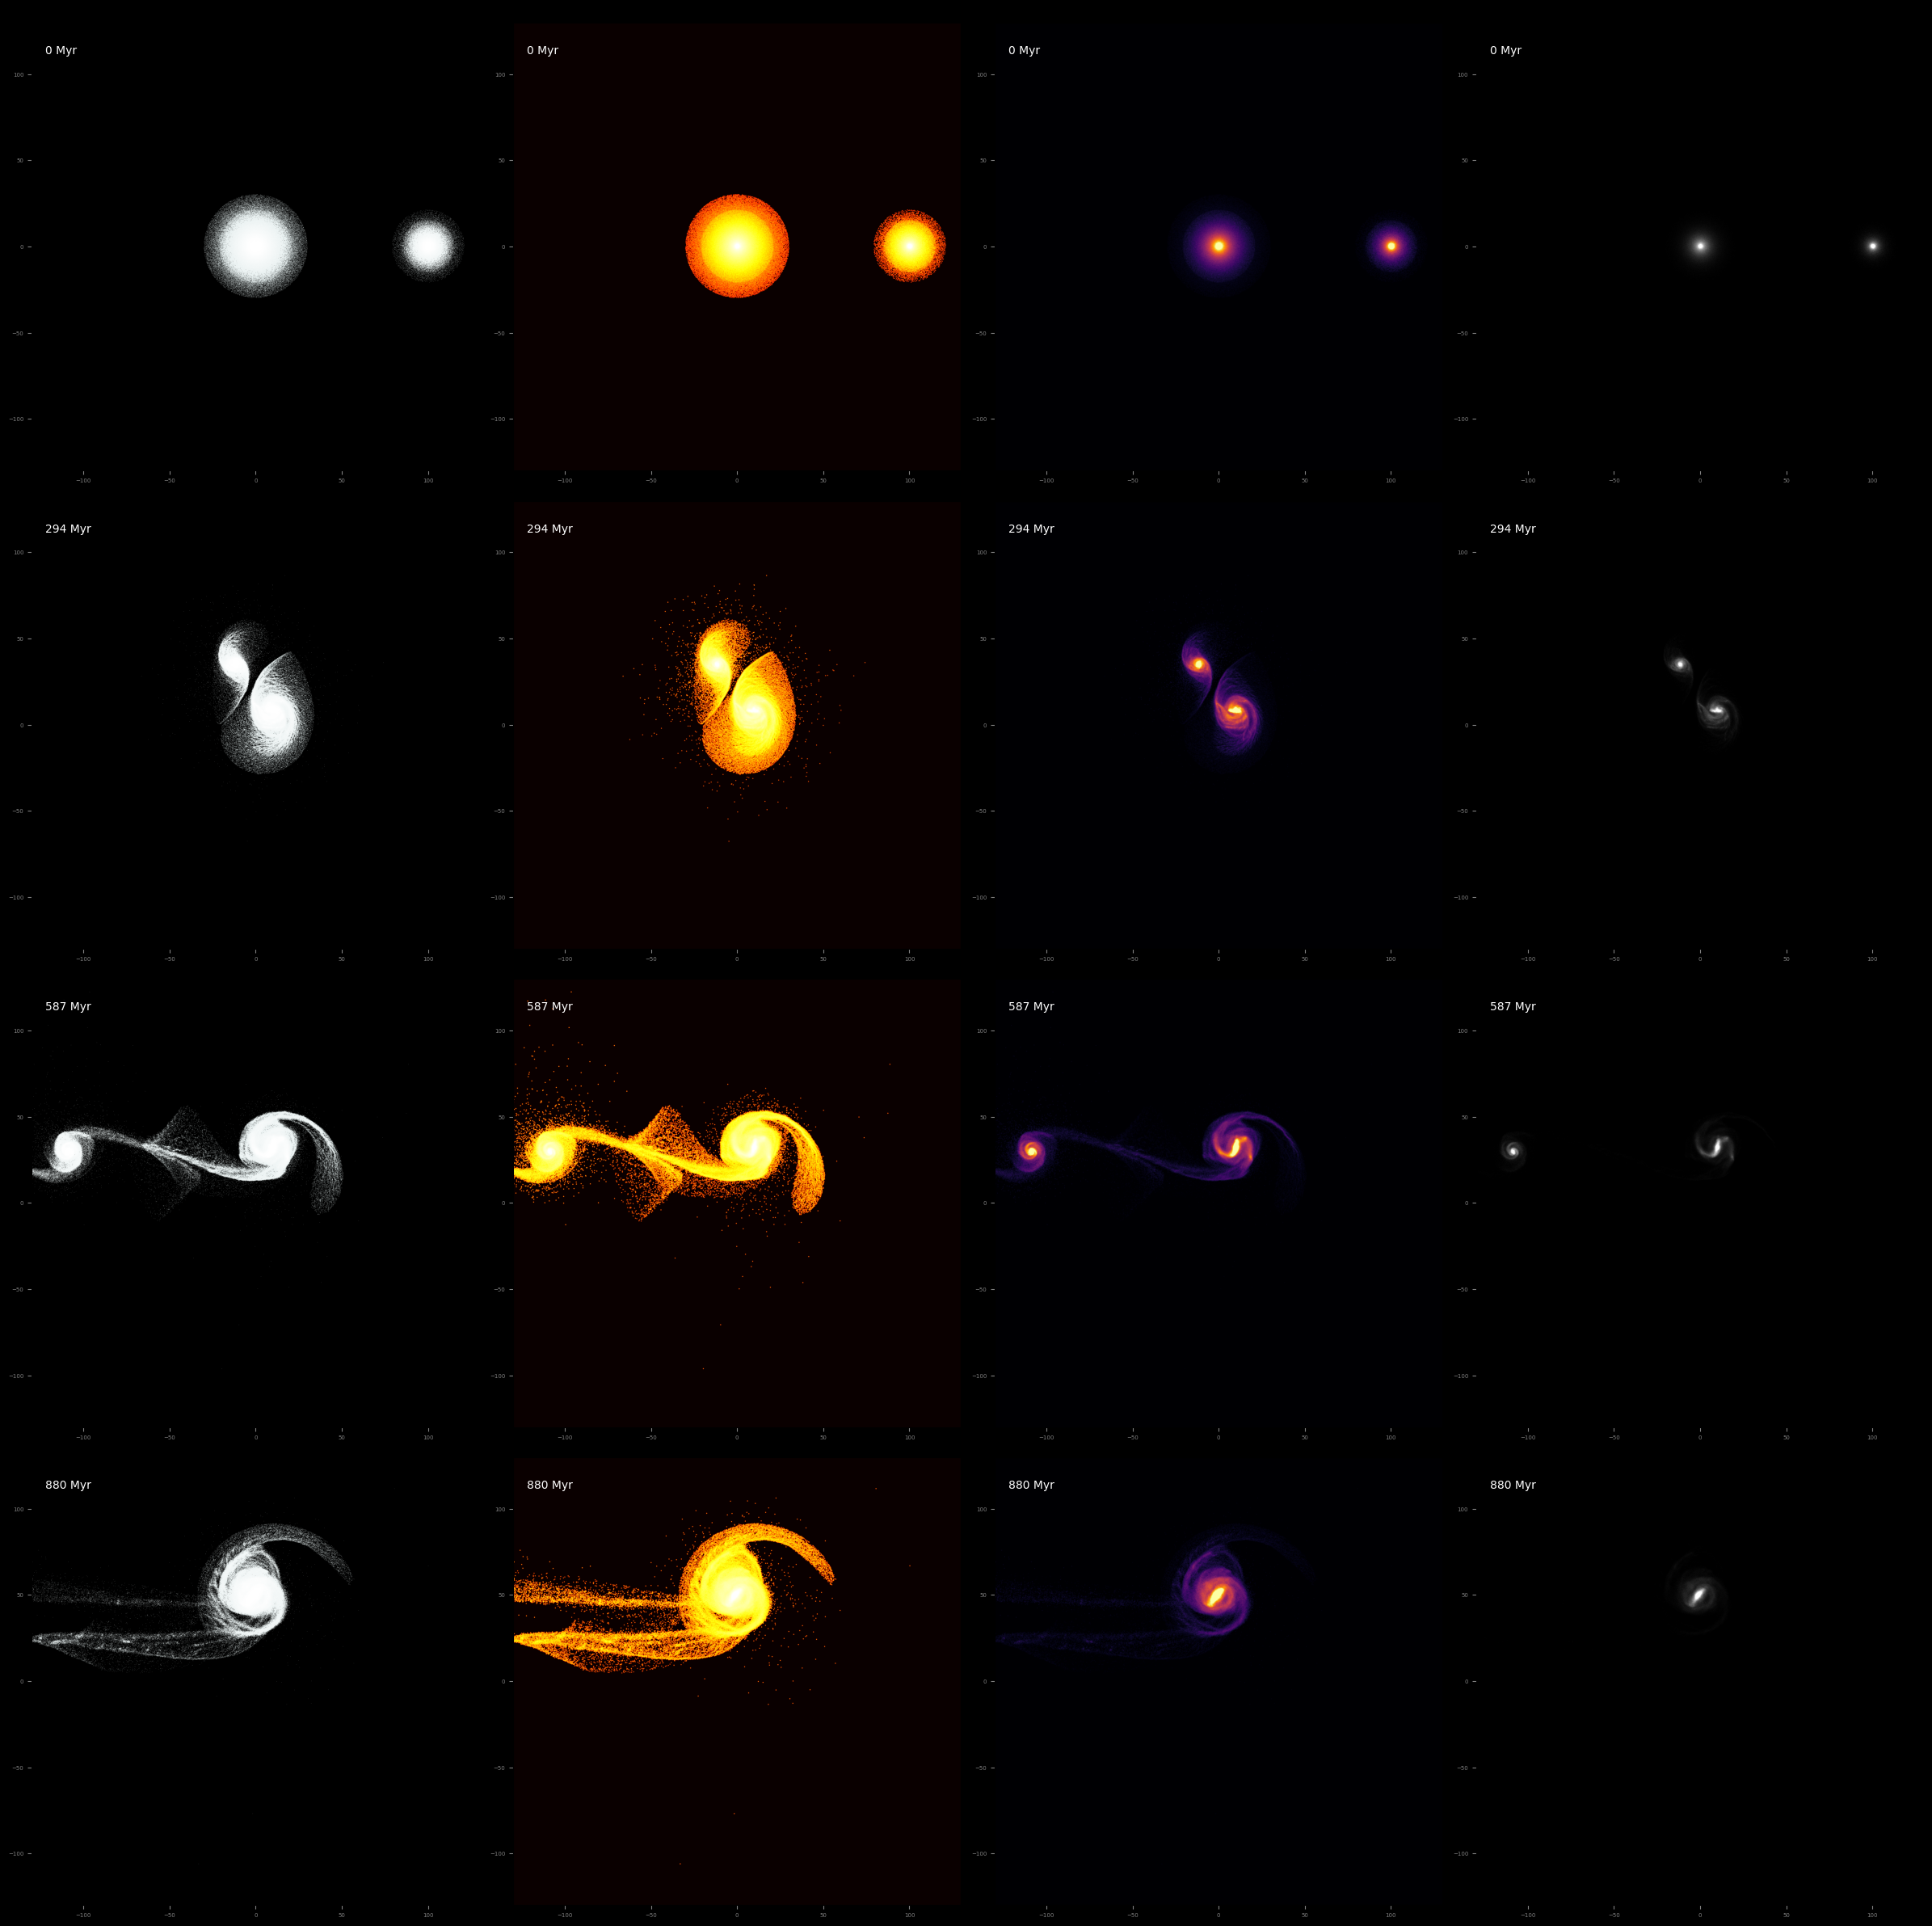

saved render_comparison.png


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

PROJECT = '/content/drive/MyDrive/galaxy_merger'
SNAPS = os.path.join(PROJECT, 'snapshots_3M')
WORK = '/content/galaxy_merger'
os.makedirs(WORK, exist_ok=True)

import shutil
if os.path.exists(os.path.join(PROJECT, 'analysis.py')):
    shutil.copy(os.path.join(PROJECT, 'analysis.py'), WORK)
sys.path.insert(0, WORK)
from analysis import read_snapshot

files = sorted(glob.glob(f'{SNAPS}/snap_*.bin'))
print(f'{len(files)} snapshots')

# picking 4 moments
picks = [0, len(files)//4, len(files)//2, int(len(files)*0.75)]
extent = 130
npix = 2000

fig, axes = plt.subplots(4, 4, figsize=(24, 24))

for row, si in enumerate(picks):
    s = read_snapshot(files[si])

    vis = (s['ptype'] == 1) | (s['ptype'] == 2) | (s['ptype'] == 3)
    x, y, m = s['x'][vis], s['y'][vis], s['mass'][vis]

    H_raw, xe, ye = np.histogram2d(x, y, bins=npix,
                                    range=[[-extent,extent],[-extent,extent]],
                                    weights=m)
    H_raw = H_raw.T

    # Style A: raw log, no smoothing, shows individual particle clumps
    ax = axes[row, 0]
    H = np.maximum(H_raw, 1e-30)
    logH = np.log10(H)
    v = logH[H > 0]
    ax.imshow(logH, extent=[-extent,extent,-extent,extent], origin='lower',
              cmap='bone', vmin=np.percentile(v, 1), vmax=np.percentile(v, 99.9))
    ax.set_title(f'{s["time_myr"]:.0f} Myr - raw log, bone' if row==0 else '', fontsize=9)

    # Style B: very light smoothing, hot colormap
    ax = axes[row, 1]
    H = gaussian_filter(H_raw, sigma=0.5)
    H = np.maximum(H, 1e-30)
    logH = np.log10(H)
    v = logH[H > 1e-20]
    ax.imshow(logH, extent=[-extent,extent,-extent,extent], origin='lower',
              cmap='hot', vmin=np.percentile(v, 2), vmax=np.percentile(v, 99.8))
    ax.set_title(f'{s["time_myr"]:.0f} Myr - sigma=0.5, hot' if row==0 else '', fontsize=9)

    # Style C: sqrt stretch instead of log, light smooth
    ax = axes[row, 2]
    H = gaussian_filter(H_raw, sigma=0.8)
    H = np.maximum(H, 0)
    sqrtH = np.sqrt(H)
    v = sqrtH[sqrtH > 0]
    ax.imshow(sqrtH, extent=[-extent,extent,-extent,extent], origin='lower',
              cmap='inferno', vmin=0, vmax=np.percentile(v, 99.5))
    ax.set_title(f'{s["time_myr"]:.0f} Myr - sqrt, inferno' if row==0 else '', fontsize=9)

    # Style D: asinh stretch, minimal smooth
    ax = axes[row, 3]
    H = gaussian_filter(H_raw, sigma=0.3)
    H = np.maximum(H, 0)
    asinhH = np.arcsinh(H * 1000) / np.arcsinh(1000)
    v = asinhH[asinhH > 0]
    ax.imshow(asinhH, extent=[-extent,extent,-extent,extent], origin='lower',
              cmap='gray', vmin=0, vmax=np.percentile(v, 99.8))
    ax.set_title(f'{s["time_myr"]:.0f} Myr - asinh, gray' if row==0 else '', fontsize=9)

    for ax in axes[row]:
        ax.set_facecolor('black')
        ax.tick_params(labelsize=5, colors='gray')
        ax.text(0.03, 0.95, f'{s["time_myr"]:.0f} Myr', transform=ax.transAxes,
                color='white', fontsize=10, va='top')

fig.patch.set_facecolor('black')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT, 'render_comparison.png'), dpi=150, facecolor='black')
plt.show()
print('saved render_comparison.png')

In [ ]:
# continuing merger simulation
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, subprocess, glob

PROJECT = '/content/drive/MyDrive/galaxy_merger'
SNAPS = os.path.join(PROJECT, 'snapshots_3M')
SNAPS2 = os.path.join(PROJECT, 'snapshots_3M_cont')
WORK = '/content/galaxy_merger'

if os.path.exists(WORK): shutil.rmtree(WORK)
shutil.copytree(PROJECT, WORK, ignore=shutil.ignore_patterns('snapshots*', 'frames*', '*.mp4', '*.bin', '*.png'))
os.makedirs(f'{WORK}/snapshots', exist_ok=True)
os.chdir(WORK)

cc = subprocess.run(['nvidia-smi','--query-gpu=compute_cap','--format=csv,noheader'],
                    capture_output=True, text=True).stdout.strip().replace('.','')
ARCH = f'sm_{cc}'
print(f'compiling for {ARCH}')
os.system(f'nvcc -O3 -arch={ARCH} -Iinclude src/gravity.cu src/main.cu -o galaxy_merger 2>&1 | tail -1')
assert os.path.exists('galaxy_merger'), 'compilation failed'

files = sorted(glob.glob(f'{SNAPS}/snap_*.bin'))
last_snap = files[-1]
print(f'restarting from {last_snap} ({len(files)} existing snapshots)')

import struct
with open(last_snap, 'rb') as f:
    f.read(7*4)  # skip counts
    t = struct.unpack('f', f.read(4))[0]
print(f'last snapshot time: {t:.3f} internal = {t*978:.0f} Myr')


os.makedirs(SNAPS2, exist_ok=True)

import threading, time as timer

stop = threading.Event()
def copier():
    local = f'{WORK}/snaps_cont'
    while not stop.is_set():
        for f in glob.glob(f'{local}/snap_*.bin'):
            dst = os.path.join(SNAPS2, os.path.basename(f))
            if not os.path.exists(dst):
                try: shutil.copy2(f, dst)
                except: pass
        stop.wait(30)

local_snaps = f'{WORK}/snaps_cont'
os.makedirs(local_snaps, exist_ok=True)

t_thread = threading.Thread(target=copier, daemon=True)
t_thread.start()

proc = subprocess.Popen(
    ['./galaxy_merger', last_snap, local_snaps, '1.534', '0.005', '0.0005'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)

for line in iter(proc.stdout.readline, ''):
    print(line.rstrip())
proc.wait()
stop.set()

for f in glob.glob(f'{local_snaps}/snap_*.bin'):
    dst = os.path.join(SNAPS2, os.path.basename(f))
    if not os.path.exists(dst): shutil.copy2(f, dst)

n_new = len(glob.glob(f'{SNAPS2}/snap_*.bin'))
n_old = len(files)
print(f'\noriginal: {n_old} snapshots')
print(f'continuation: {n_new} snapshots')
print(f'total: {n_old + n_new} snapshots covering ~2.7 Gyr')

Mounted at /content/drive
compiling for sm_80
restarting from /content/drive/MyDrive/galaxy_merger/snapshots_3M/snap_0240.bin (241 existing snapshots)
last snapshot time: 1.200 internal = 1174 Myr
loaded 3150002 particles
read 9 fields
GPU memory: 132 MB
  snap 0000  t=0 Myr

running 1500 Myr, dt=0.5 Myr, saving every 4.9 Myr

  snap 0001  t=5 Myr
  snap 0002  t=10 Myr
  snap 0003  t=15 Myr
  snap 0004  t=20 Myr
  snap 0005  t=25 Myr
  snap 0006  t=30 Myr
  snap 0007  t=35 Myr
  snap 0008  t=40 Myr
  snap 0009  t=44 Myr
  snap 0010  t=49 Myr
  snap 0011  t=54 Myr
  snap 0012  t=59 Myr
  snap 0013  t=64 Myr
  snap 0014  t=68 Myr
  snap 0015  t=73 Myr
  snap 0016  t=78 Myr
  snap 0017  t=83 Myr
  snap 0018  t=88 Myr
  snap 0019  t=93 Myr
  snap 0020  t=98 Myr
step    200  t=98 Myr  2258.6 ms/step  ETA 1.8 h
  snap 0021  t=103 Myr
  snap 0022  t=108 Myr
  snap 0023  t=112 Myr
  snap 0024  t=117 Myr
  snap 0025  t=122 Myr
  snap 0026  t=127 Myr
  snap 0027  t=132 Myr
  snap 0028  t=137 Myr